# 03-Finance Tutorial- Pricing European Call Options
### Modified for Quantum Rings toolkit for Qiskit 2.x

In [3]:
# This code is from:
# https://qiskit-community.github.io/qiskit-finance/tutorials/03_european_call_option_pricing.html

# Modified for use with Quantum Rings toolkit

In [4]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#
import os

my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [5]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

from qiskit import QuantumCircuit
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
#from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution

from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrSamplerV2 as Sampler

#
# Acquire Quantum Rings Backend
#

qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

In [6]:
# number of qubits to represent the uncertainty
num_uncertainty_qubits = 3

# parameters for considered random distribution
S = 2.0  # initial spot price
vol = 0.4  # volatility of 40%
r = 0.05  # annual interest rate of 4%
T = 40 / 365  # 40 days to maturity

# resulting parameters for log-normal distribution
mu = (r - 0.5 * vol**2) * T + np.log(S)
sigma = vol * np.sqrt(T)
mean = np.exp(mu + sigma**2 / 2)
variance = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
stddev = np.sqrt(variance)

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = np.maximum(0, mean - 3 * stddev)
high = mean + 3 * stddev

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
uncertainty_model = LogNormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma=sigma**2, bounds=(low, high)
)

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
C:\Users\vkasi\AppData\Local\Temp\ipykernel_21124\2885665035.py:8: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
C:\Users\vkasi\AppData\Local\Temp\ipykernel_21124\2885665035.py:9: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel("Probability ($\%$)", size=15)


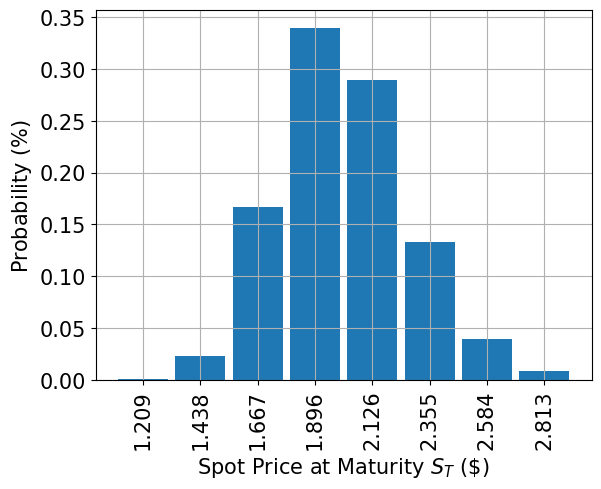

In [7]:
# plot probability distribution
x = uncertainty_model.values
y = uncertainty_model.probabilities
plt.bar(x, y, width=0.2)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.grid()
plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
plt.ylabel("Probability ($\%$)", size=15)
plt.show()

In [8]:
# set the strike price (should be within the low and the high value of the uncertainty)
strike_price = 1.896

# set the approximation scaling for the payoff function
c_approx = 0.25

# setup piecewise linear objective fcuntion
breakpoints = [low, strike_price]
slopes = [0, 1]
offsets = [0, 0]
f_min = 0
f_max = high - strike_price
european_call_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
    rescaling_factor=c_approx,
)

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
num_qubits = european_call_objective.num_qubits
european_call = QuantumCircuit(num_qubits)
european_call.append(uncertainty_model, range(num_uncertainty_qubits))
european_call.append(european_call_objective, range(num_qubits))

# draw the circuit
european_call.draw()

C:\Users\vkasi\AppData\Local\Temp\ipykernel_21124\944600917.py:13: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_call_objective = LinearAmplitudeFunction(


┌───────┐┌────┐
q_0: ┤0      ├┤0   ├
     │       ││    │
q_1: ┤1 P(X) ├┤1   ├
     │       ││    │
q_2: ┤2      ├┤2   ├
     └───────┘│    │
q_3: ─────────┤3 F ├
              │    │
q_4: ─────────┤4   ├
              │    │
q_5: ─────────┤5   ├
              │    │
q_6: ─────────┤6   ├
              └────┘

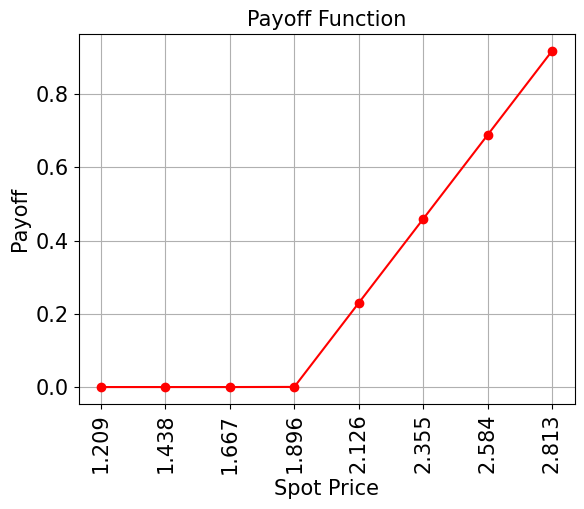

In [9]:
# plot exact payoff function (evaluated on the grid of the uncertainty model)
x = uncertainty_model.values
y = np.maximum(0, x - strike_price)
plt.plot(x, y, "ro-")
plt.grid()
plt.title("Payoff Function", size=15)
plt.xlabel("Spot Price", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.show()

In [10]:
# evaluate exact expected value (normalized to the [0, 1] interval)
exact_value = np.dot(uncertainty_model.probabilities, y)
exact_delta = sum(uncertainty_model.probabilities[x >= strike_price])
print("exact expected value:\t%.4f" % exact_value)
print("exact delta value:   \t%.4f" % exact_delta)

exact expected value:	0.1623
exact delta value:   	0.8098


In [11]:
european_call.draw()

┌───────┐┌────┐
q_0: ┤0      ├┤0   ├
     │       ││    │
q_1: ┤1 P(X) ├┤1   ├
     │       ││    │
q_2: ┤2      ├┤2   ├
     └───────┘│    │
q_3: ─────────┤3 F ├
              │    │
q_4: ─────────┤4   ├
              │    │
q_5: ─────────┤5   ├
              │    │
q_6: ─────────┤6   ├
              └────┘

In [12]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_call,
    objective_qubits=[3],
    post_processing=european_call_objective.post_processing,
)
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(backend=qr_backend, options={"shots": 100, "seed": 75})
)

In [13]:
result = ae.estimate(problem)

In [14]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (result.estimation_processed))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	0.1623
Estimated value:    	0.1695
Confidence interval:	[0.1644, 0.1747]


In [15]:
# Example output:
# Exact value:        	0.1623
# Estimated value:    	0.1704
# Confidence interval:	[0.1620, 0.1789]

In [16]:
import tutorial_magics

%qiskit_version_table
%quantumrings_version_table
%qiskit_copyright

Software,Version
QuantumRingsLib,0.11.0
quantumrings-toolkit-qiskit,0.1.10
